# CityLearn simulation environemnt EDA `citylearn_challenge_2023_phase_3_1`

# Show plot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from citylearn.citylearn import CityLearnEnv

In [2]:
# ==========================================
# 1. Environment Initialization
# ==========================================
base_schema = "citylearn_challenge_2023_phase_3_1"
env = CityLearnEnv(schema=base_schema)

INFO:root:Go here /home/ntpt/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


In [3]:
# ==========================================
# 2. In-Memory Data Extraction
# ==========================================
def extract_env_data(env):
    """Extracts full time-series data directly from the instantiated environment."""
    all_data = []

    for b in env.buildings:
        # Access the underlying energy simulation arrays directly
        df = pd.DataFrame(
            {
                "Building_ID": b.name,
                "Equipment_Electric_Power_[kWh]": b.energy_simulation.non_shiftable_load,
                "Solar_Generation_[W/kW]": b.energy_simulation.solar_generation,
                "Indoor_Temperature_[C]": b.energy_simulation.indoor_dry_bulb_temperature,
                "Cooling_Demand_[kWh]": b.energy_simulation.cooling_demand,
            }
        )

        # Add temporal features (CityLearn default is 1-hour steps)
        df["Hour"] = df.index % 24
        all_data.append(df)

    return pd.concat(all_data, ignore_index=True)


df = extract_env_data(env)

In [4]:
df

,Building_ID,Equipment_Electric_Power_[kWh],Solar_Generation_[W/kW],Indoor_Temperature_[C],Cooling_Demand_[kWh],Hour
0,Building_1,0.356269,0.0,22.428127,0.000000,0
1,Building_1,0.344522,0.0,22.223213,0.227737,1
2,Building_1,0.338227,0.0,22.222225,0.132294,2
3,Building_1,0.334329,0.0,22.222227,0.152979,3
4,Building_1,0.348094,0.0,22.222225,0.119001,4
...,...,...,...,...,...,...
13243,Building_6,0.460488,0.0,25.555552,4.097681,19
13244,Building_6,0.446670,0.0,25.555559,3.707924,20
13245,Building_6,0.449183,0.0,25.226774,3.790312,21
13246,Building_6,0.407726,0.0,24.464525,4.427861,22


In [5]:
# ==========================================
# 3. Summary Statistics (Per Feature)
# ==========================================
print("--- Summary Statistics by Building ---")

# Define the core features we want to analyze, ignoring temporal metadata like 'Hour'
features_to_summarize = [
    "Equipment_Electric_Power_[kWh]",
    "Solar_Generation_[W/kW]",
    "Indoor_Temperature_[C]",
    "Cooling_Demand_[kWh]",
]

# Iterate through each feature and print its summary table separately
for feature in features_to_summarize:
    if feature in df.columns:
        print(f"\n{'-'*40}")
        print(f"🔹 Feature: {feature}")
        print(f"{'-'*40}")

        # Group by building and calculate stats for just this feature
        feature_summary = df.groupby("Building_ID")[feature].agg(["mean", "std", "min", "max"])

        # Round the values for cleaner display
        print(feature_summary.round(3).to_string())
print(f"\n{'-'*40}")

--- Summary Statistics by Building ---

----------------------------------------
🔹 Feature: Equipment_Electric_Power_[kWh]
----------------------------------------
              mean    std    min     max
Building_ID                             
Building_1   0.612  0.815  0.308   7.459
Building_2   0.455  0.665  0.168   8.825
Building_3   0.874  0.843  0.396   8.475
Building_4   0.885  0.891  0.551  11.247
Building_5   0.631  0.561  0.450   8.396
Building_6   0.660  0.611  0.310   5.853

----------------------------------------
🔹 Feature: Solar_Generation_[W/kW]
----------------------------------------
                mean      std  min      max
Building_ID                                
Building_1   181.966  228.982  0.0  712.919
Building_2   181.966  228.982  0.0  712.919
Building_3   181.966  228.982  0.0  712.919
Building_4   181.966  228.982  0.0  712.919
Building_5   181.966  228.982  0.0  712.919
Building_6   181.966  228.982  0.0  712.919

-------------------------------------

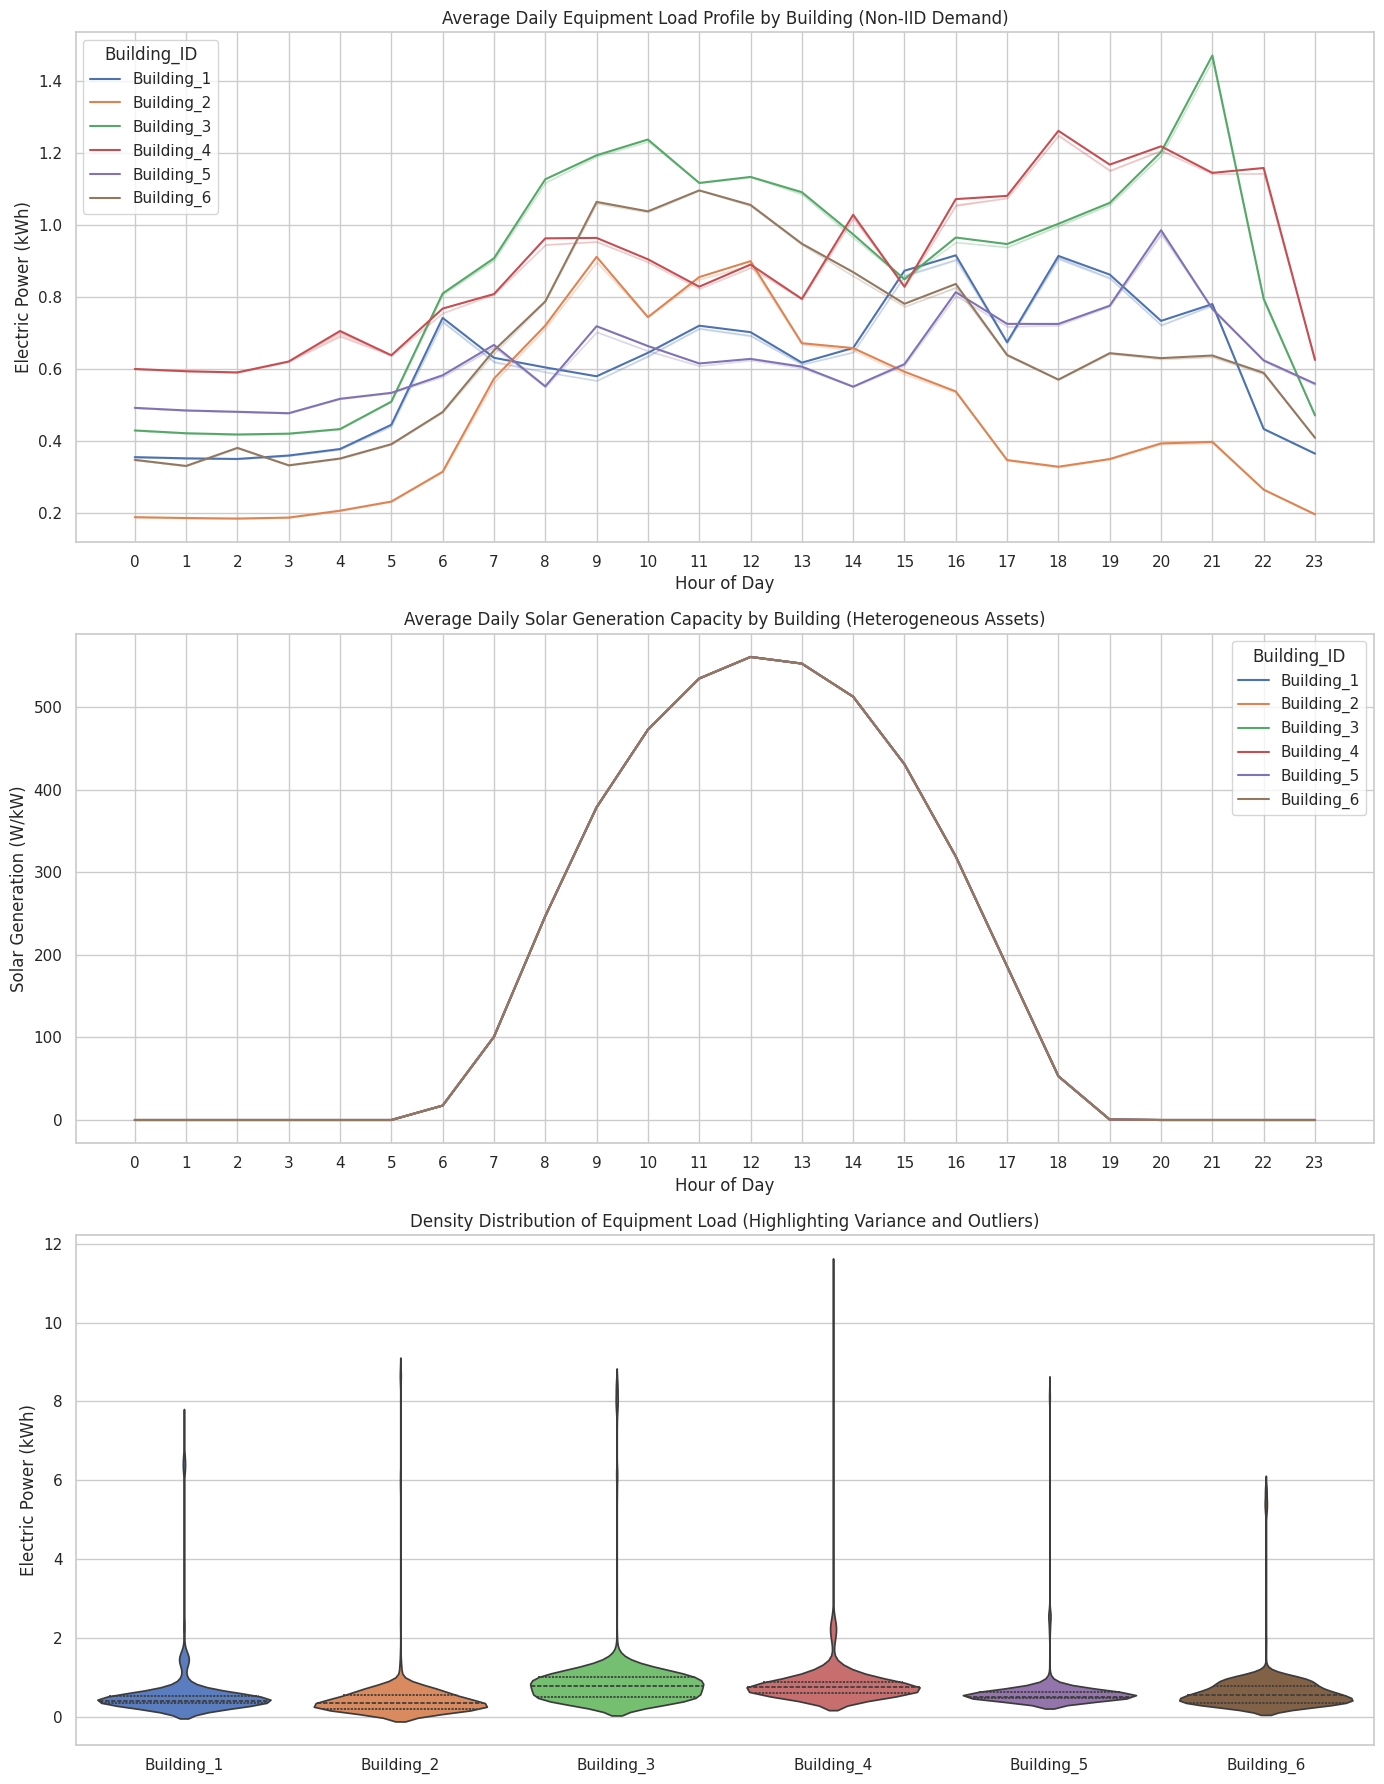

In [7]:
# ==========================================
# 4. Visualizations: Building Heterogeneity
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Plot A: Average Daily Load Profiles
sns.lineplot(
    data=df,
    x="Hour",
    y="Equipment_Electric_Power_[kWh]",
    hue="Building_ID",
    errorbar=("ci", 1),
    ax=axes[0],
)
axes[0].set_title("Average Daily Equipment Load Profile by Building (Non-IID Demand)")
axes[0].set_ylabel("Electric Power (kWh)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_xticks(range(0, 24))

# Plot B: Solar Generation Profiles
sns.lineplot(
    data=df, x="Hour", y="Solar_Generation_[W/kW]", hue="Building_ID", errorbar=None, ax=axes[1]
)
axes[1].set_title("Average Daily Solar Generation Capacity by Building (Heterogeneous Assets)")
axes[1].set_ylabel("Solar Generation (W/kW)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_xticks(range(0, 24))

# Plot C: Distribution of Loads (Density & Variance)
sns.violinplot(
    data=df,
    x="Building_ID",
    y="Equipment_Electric_Power_[kWh]",
    hue="Building_ID",
    palette="muted",
    inner="quartile",
    ax=axes[2],
)
axes[2].set_title("Density Distribution of Equipment Load (Highlighting Variance and Outliers)")
axes[2].set_ylabel("Electric Power (kWh)")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

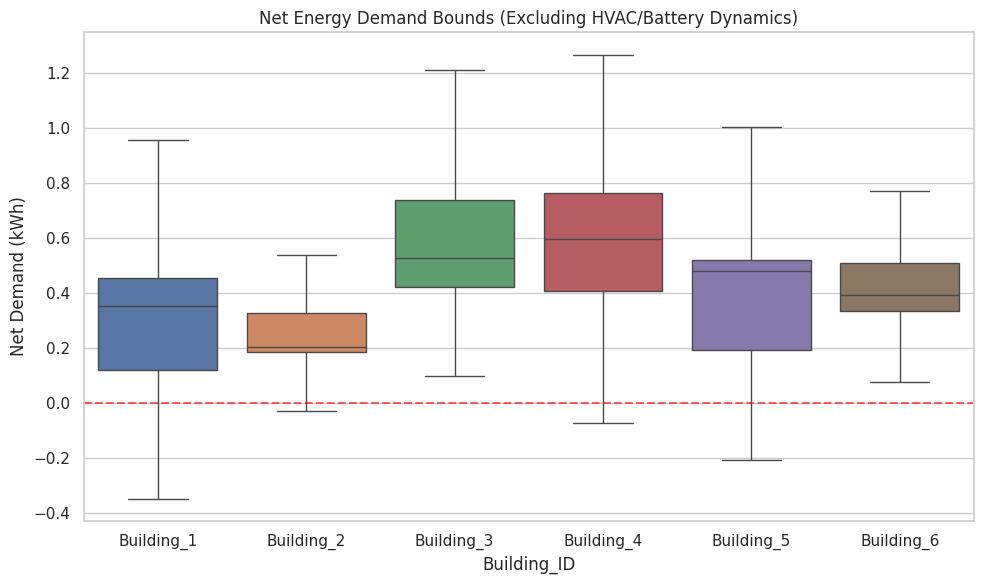

In [7]:
# ==========================================
# 5. Net Demand Calculation & Plot
# ==========================================
# Calculate Net Demand (Load + Cooling - Solar equivalent)
# Note: In a rigorous MARL setup, cooling demand must be converted by COP to get electrical load.
# Here we approximate net electrical bounds using raw non-shiftable load and solar.
df["Net_Demand_[kWh]"] = df["Equipment_Electric_Power_[kWh]"] - (
    df["Solar_Generation_[W/kW]"] / 1000
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Building_ID", y="Net_Demand_[kWh]", hue="Building_ID", showfliers=False)
plt.title("Net Energy Demand Bounds (Excluding HVAC/Battery Dynamics)")
plt.ylabel("Net Demand (kWh)")
plt.axhline(0, color="red", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

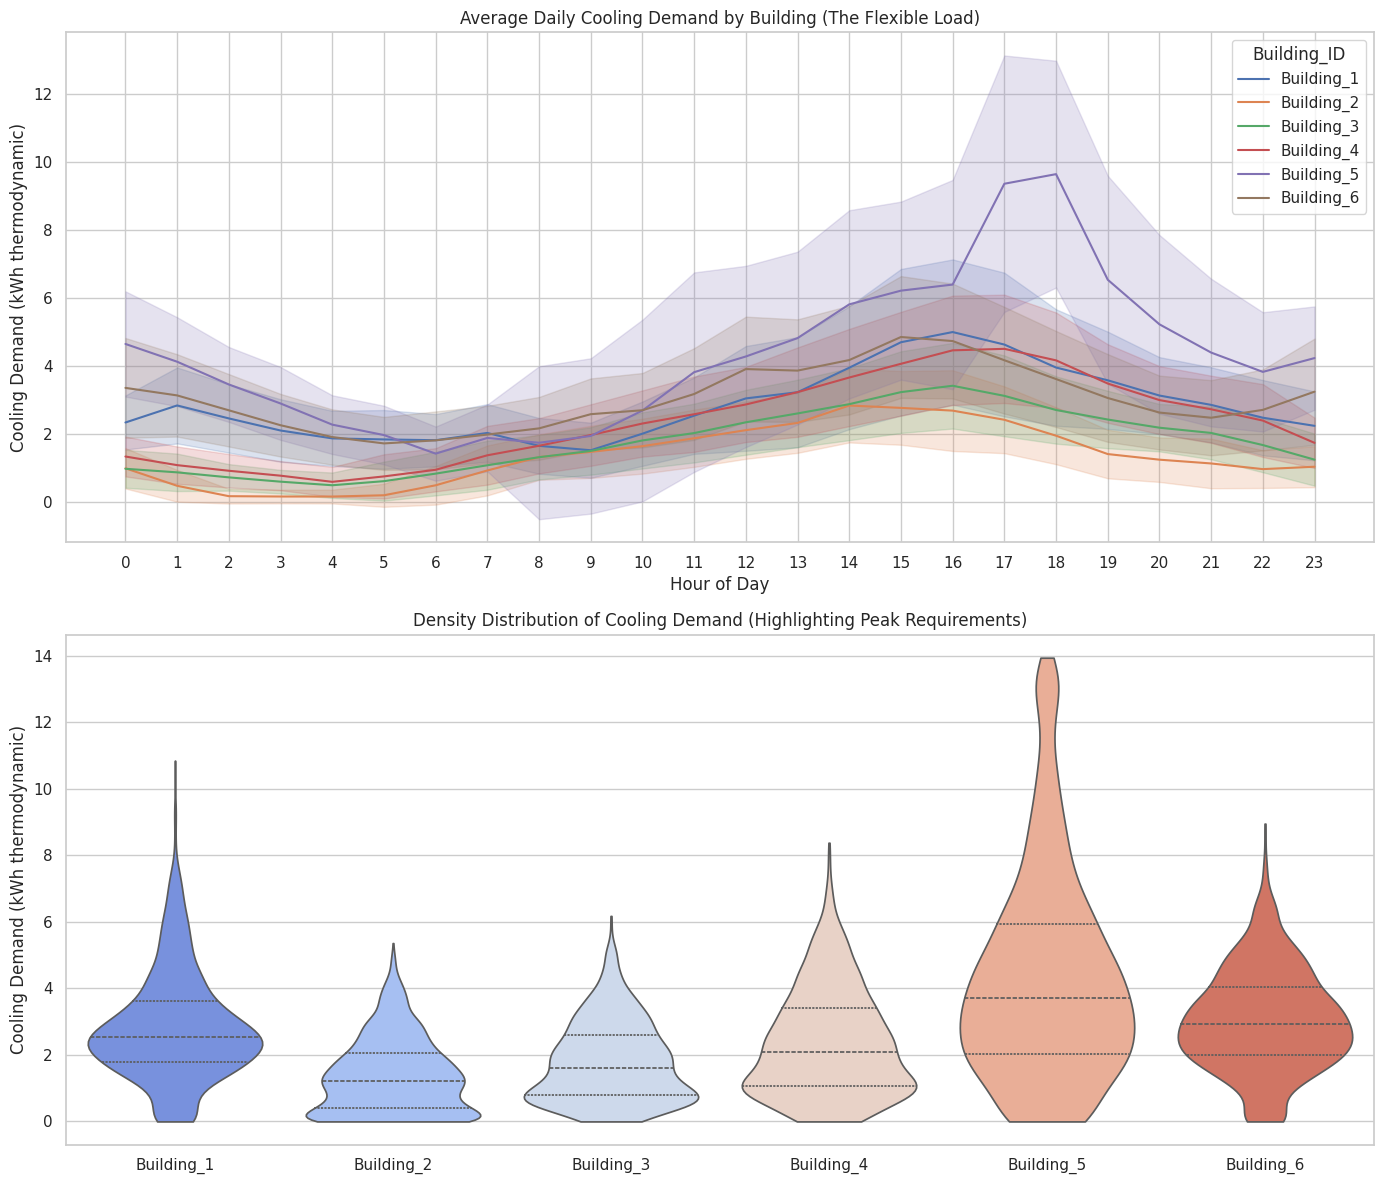

In [8]:
# ==========================================
# 6. Visualizations: Cooling Demand Dynamics
# ==========================================
# Create a new figure specifically for thermal analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot A: Average Daily Cooling Profile
sns.lineplot(
    data=df, x="Hour", y="Cooling_Demand_[kWh]", hue="Building_ID", errorbar="sd", ax=axes[0]
)
axes[0].set_title("Average Daily Cooling Demand by Building (The Flexible Load)")
axes[0].set_ylabel("Cooling Demand (kWh thermodynamic)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_xticks(range(0, 24))

# Plot B: Density Distribution of Cooling Demand
sns.violinplot(
    data=df,
    x="Building_ID",
    y="Cooling_Demand_[kWh]",
    hue="Building_ID",
    palette="coolwarm",  # Using a temperature-themed palette
    inner="quartile",
    cut=0,
    ax=axes[1],
)
axes[1].set_title("Density Distribution of Cooling Demand (Highlighting Peak Requirements)")
axes[1].set_ylabel("Cooling Demand (kWh thermodynamic)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

# Export

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from citylearn.citylearn import CityLearnEnv

In [10]:
# ==========================================
# 1. Environment Initialization
# ==========================================
base_schema = "citylearn_challenge_2023_phase_3_1"
env = CityLearnEnv(schema=base_schema)

INFO:root:Go here /home/ntpt/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


In [11]:
# ==========================================
# 2. In-Memory Data Extraction
# ==========================================
def extract_env_data(env):
    """Extracts full time-series data directly from the instantiated environment."""
    all_data = []

    for b in env.buildings:
        df = pd.DataFrame(
            {
                "Building_ID": b.name,
                "Equipment_Electric_Power_[kWh]": b.energy_simulation.non_shiftable_load,
                "Solar_Generation_[W/kW]": b.energy_simulation.solar_generation,
                "Indoor_Temperature_[C]": b.energy_simulation.indoor_dry_bulb_temperature,
                "Cooling_Demand_[kWh]": b.energy_simulation.cooling_demand,
            }
        )

        # Add temporal features (CityLearn default is 1-hour steps)
        df["Hour"] = df.index % 24
        all_data.append(df)

    return pd.concat(all_data, ignore_index=True)


df = extract_env_data(env)

# Pre-calculate Net Demand for later plotting
df["Net_Demand_[kWh]"] = df["Equipment_Electric_Power_[kWh]"] - (
    df["Solar_Generation_[W/kW]"] / 1000
)

In [12]:
# ==========================================
# 3. Independent Visualizations & Exports
# ==========================================
sns.set_theme(style="whitegrid")

# --- Plot 1: Average Daily Load Profiles ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="Hour",
    y="Equipment_Electric_Power_[kWh]",
    hue="Building_ID",
    errorbar=("ci", 70),
)
plt.title("Average Daily Equipment Load Profile by Building (Non-IID Demand)")
plt.ylabel("Electric Power (kWh)")
plt.xlabel("Hour of Day")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("01_equipment_load_profile.png", dpi=300)
plt.close()

# --- Plot 2: Solar Generation Profiles ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Hour", y="Solar_Generation_[W/kW]", hue="Building_ID", errorbar=None)
plt.title("Average Daily Solar Generation Capacity by Building (Heterogeneous Assets)")
plt.ylabel("Solar Generation (W/kW)")
plt.xlabel("Hour of Day")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("02_solar_generation_profile.png", dpi=300)
plt.close()

# --- Plot 3: Density Distribution of Loads ---
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Building_ID",
    y="Equipment_Electric_Power_[kWh]",
    hue="Building_ID",
    palette="muted",
    inner="quartile",
)
plt.title("Density Distribution of Equipment Load (Highlighting Variance and Outliers)")
plt.ylabel("Electric Power (kWh)")
plt.xlabel("Building ID")
plt.tight_layout()
plt.savefig("03_equipment_load_density.png", dpi=300)
plt.close()

# --- Plot 4: Net Demand Bounds ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Building_ID", y="Net_Demand_[kWh]", hue="Building_ID", showfliers=False)
plt.title("Net Energy Demand Bounds (Excluding HVAC/Battery Dynamics)")
plt.ylabel("Net Demand (kWh)")
plt.xlabel("Building ID")
plt.axhline(0, color="red", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("04_net_demand_bounds.png", dpi=300)
plt.close()

# --- Plot 5: Average Daily Cooling Demand ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Hour", y="Cooling_Demand_[kWh]", hue="Building_ID", errorbar="sd")
plt.title("Average Daily Cooling Demand by Building (The Flexible Load)")
plt.ylabel("Cooling Demand (kWh thermodynamic)")
plt.xlabel("Hour of Day")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("05_cooling_demand_profile.png", dpi=300)
plt.close()

# --- Plot 6: Density Distribution of Cooling Demand ---
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Building_ID",
    y="Cooling_Demand_[kWh]",
    hue="Building_ID",
    palette="coolwarm",
    inner="quartile",
    cut=0,
)
plt.title("Density Distribution of Cooling Demand (Highlighting Peak Requirements)")
plt.ylabel("Cooling Demand (kWh thermodynamic)")
plt.xlabel("Building ID")
plt.tight_layout()
plt.savefig("06_cooling_demand_density.png", dpi=300)
plt.close()

print("All 6 plots successfully generated and exported.")

All 6 plots successfully generated and exported.
